# Replication — Hong & Kacperczyk (2009), *"The Price of Sin"*

This notebook replicates the **main return tests** from:

> Hong, H. & Kacperczyk, M. (2009). *The Price of Sin: The Effects of Social Norms on Markets.*
> Journal of Financial Economics, 93(1), 15–36.

---

## Roadmap

| Section | Description |
|---------|-------------|
| **0** | Setup & WRDS Connection |
| **1** | Identifying Sin Stocks (Alcohol, Tobacco, Gaming) |
| **2** | Identifying Comparable Stocks (Food, Soda, Fun, Meals) |
| **3** | Pulling Monthly CRSP Returns & Delisting Adjustments |
| **4** | Constructing Equal-Weighted Portfolios |
| **5** | Downloading Fama–French / Carhart Factor Data |
| **6** | Asset-Pricing Regressions (CAPM, 4-Factor, 5-Factor) |
| **7** | Extensions (rolling windows, Fama–MacBeth, VW portfolios) |

---

### Key Definitions (from the paper)

**Sin stocks** are firms in three "vice" industries:

| Industry | Source | Codes |
|----------|--------|-------|
| **Alcohol** | FF48 #4 ("Beer") & FF48 #5 ("Smoke" — partial) | SIC 2080–2085 (Beer & Liquor) |
| **Tobacco** | FF48 #5 ("Smoke") | SIC 2100–2199 |
| **Gaming** | NAICS-based | NAICS 7132, 71312, 713210, 71329, 713290, 72112, 721120 |

**Comparable stocks** are firms in "fun-consumption" industries that share demand-side characteristics but are *not* socially controversial:

| Industry | FF48 Code | SIC Ranges |
|----------|-----------|------------|
| **Food** | FF48 #1 | 2000–2046, 2048–2099 |
| **Soda** | FF48 #3 | 2064–2068, 2086–2087, 2095–2098 |
| **Fun** | FF48 #7 | 7800–7833, 7840–7841, 7900–7999 |
| **Meals & Hotels** | FF48 #43 | 5800–5813, 5890, 7000–7000, 7010–7019, 7040–7049, 7213 |

## 0 — Setup & WRDS Connection

In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import wrds
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_hac
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# ── WRDS Connection ─────────────────────────────────────────────────────────
# Uses ~/.pgpass or prompts for credentials
db = wrds.Connection()
print("✅ Connected to WRDS —", db.engine.url.database)

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Connected to WRDS — wrds
Done
✅ Connected to WRDS — wrds


In [7]:
# ── Sample Period ────────────────────────────────────────────────────────────
# Original paper: 1965-01 to 2006-12
# Extended sample: 1965-01 to 2025-12
BEG_DATE = "1965-01-01"
END_DATE = "2025-12-31"

print(f"Sample window: {BEG_DATE} → {END_DATE}")

Sample window: 1965-01-01 → 2025-12-31


## 1 — Identifying Sin Stocks

### Strategy

Hong & Kacperczyk (2009) identify sin stocks using **three channels**:

1. **Alcohol (SIC-based):**  
   - SIC 2080–2085 → Fama–French 48 industry #4 ("Beer")  
   - These cover malt beverages, malt, wines/brandy/spirits, bottled & canned soft drinks (2086 is soda — excluded), distilled liquor  

2. **Tobacco (SIC-based):**  
   - SIC 2100–2199 → Fama–French 48 industry #5 ("Smoke")  
   - Cigarettes, cigars, chewing/smoking tobacco, tobacco stemming & redrying  

3. **Gaming (NAICS-based):**  
   - The paper uses NAICS codes from Compustat segments to flag firms with **any** gaming segment  
   - Key NAICS: `7132xx` (Gambling Industries), `72112x` (Casino Hotels)  
   - This captures firms like Las Vegas Sands, Wynn, MGM, etc.  
   - Firms are flagged if *any* business segment has a gaming NAICS code  

### Sample Filters (applied to all firms)
- **CRSP share codes:** `SHRCD ∈ {10, 11}` (ordinary common shares, US-incorporated)
- **Exclude financials:** `SIC NOT BETWEEN 6000 AND 6999`
- **Require valid CRSP–Compustat link:** via CCM `CCMXPF_LNKHIST` with `LINKTYPE ∈ ('LU','LC')` and `LINKPRIM ∈ ('P','C')`

In [10]:
# ── Diagnostic: discover actual CRSP table schemas on this WRDS instance ─────
for tbl in ["crsp.msf", "crsp.msenames", "crsp.stocknames", "crsp.msedelist"]:
    try:
        cols = db.raw_sql(f"SELECT column_name FROM information_schema.columns WHERE table_schema || '.' || table_name = '{tbl}' ORDER BY ordinal_position")
        print(f"\n✅ {tbl} columns:\n  {', '.join(cols['column_name'].tolist())}")
    except Exception as e:
        print(f"\n❌ {tbl}: {e}")


✅ crsp.msf columns:
  cusip, permno, permco, issuno, hexcd, hsiccd, date, bidlo, askhi, prc, vol, ret, bid, ask, shrout, cfacpr, cfacshr, altprc, spread, altprcdt, retx

✅ crsp.msenames columns:
  permno, namedt, nameendt, shrcd, exchcd, siccd, ncusip, ticker, comnam, shrcls, tsymbol, naics, primexch, trdstat, secstat, permco, compno, issuno, hexcd, hsiccd, cusip

✅ crsp.stocknames columns:
  permno, namedt, nameenddt, shrcd, exchcd, siccd, ncusip, ticker, comnam, shrcls, permco, hexcd, cusip, st_date, end_date, namedum

✅ crsp.msedelist columns:
  permno, dlstdt, dlstcd, nwperm, nwcomp, nextdt, dlamt, dlretx, dlprc, dlpdt, dlret, permco, compno, issuno, hexcd, hsiccd, cusip, acperm, accomp


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1A · Build the CRSP–Compustat merged universe with SIC codes
# ═══════════════════════════════════════════════════════════════════════════════
#
# WRDS CRSP schema on this instance:
#   crsp.msf       → permno, date, ret, prc, shrout  (NO shrcd, siccd, dlret)
#   crsp.msenames  → permno, namedt, nameendt, shrcd, siccd, naics
#   crsp.msedelist → permno, dlstdt, dlret
#   crsp.ccmxpf_lnkhist → lpermno, gvkey, linkdt, linkenddt, linktype, linkprim
#   comp.company   → gvkey, sic, naics
#
# Strategy: join msenames on (permno, date between namedt and nameendt) to get
# shrcd / siccd, then filter shrcd ∈ (10,11). Join msedelist for dlret.

ccm_query = f"""
SELECT DISTINCT
    a.permno,
    a.date,
    a.ret,
    d.dlret,
    a.prc,
    a.shrout,
    n.shrcd,
    n.siccd       AS sic_crsp,
    n.naics       AS naics_crsp,
    l.gvkey,
    c.sic         AS sic_comp,
    c.naics       AS naics_comp
FROM crsp.msf AS a

/* ── CRSP Names: shrcd, siccd, naics ─────────────────────────────── */
INNER JOIN crsp.msenames AS n
    ON a.permno = n.permno
    AND a.date >= n.namedt
    AND a.date <= n.nameendt

/* ── CCM link: CRSP ↔ Compustat ──────────────────────────────────── */
INNER JOIN crsp.ccmxpf_lnkhist AS l
    ON a.permno = l.lpermno
    AND l.linktype  IN ('LU', 'LC')
    AND l.linkprim  IN ('P', 'C')
    AND (l.linkdt  <= a.date OR l.linkdt IS NULL)
    AND (l.linkenddt >= a.date OR l.linkenddt IS NULL)

/* ── Compustat company header (SIC / NAICS fallback) ─────────────── */
LEFT JOIN comp.company AS c
    ON l.gvkey = c.gvkey

/* ── CRSP delisting events (source of dlret) ─────────────────────── */
LEFT JOIN crsp.msedelist AS d
    ON a.permno = d.permno
    AND DATE_TRUNC('month', a.date) = DATE_TRUNC('month', d.dlstdt)

WHERE a.date BETWEEN '{BEG_DATE}' AND '{END_DATE}'
  AND n.shrcd IN (10, 11)
"""

print("⏳ Pulling CRSP–Compustat linked universe (this may take a few minutes)…")
crsp_raw = db.raw_sql(ccm_query, date_cols=["date"])
print(f"✅ Pulled {len(crsp_raw):,} firm-month rows, {crsp_raw['permno'].nunique():,} unique PERMNOs")

⏳ Pulling CRSP–Compustat linked universe (this may take a few minutes)…
✅ Pulled 3,200,033 firm-month rows, 23,266 unique PERMNOs
✅ Pulled 3,200,033 firm-month rows, 23,266 unique PERMNOs


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1B · Clean SIC, compute market cap, handle delisting returns
# ═══════════════════════════════════════════════════════════════════════════════

df = crsp_raw.copy()

# ── Resolve SIC: prefer CRSP, fall back to Compustat ─────────────────────────
df["sic"] = df["sic_crsp"].fillna(df["sic_comp"])
df["sic"] = pd.to_numeric(df["sic"], errors="coerce")

# ── Exclude financials (SIC 6000–6999) ───────────────────────────────────────
df = df[~((df["sic"] >= 6000) & (df["sic"] <= 6999))].copy()

# ── Adjust returns for delistings (Shumway 1997 / CRSP methodology) ──────────
# If DLRET exists, compound: (1+RET)*(1+DLRET) - 1
# If delisted but DLRET missing, assume –30% for performance delistings
df["ret"]   = pd.to_numeric(df["ret"],   errors="coerce")
df["dlret"] = pd.to_numeric(df["dlret"], errors="coerce")

df["ret_adj"] = df["ret"]
mask_dlret = df["dlret"].notna()
df.loc[mask_dlret, "ret_adj"] = (
    (1 + df.loc[mask_dlret, "ret"].fillna(0)) *
    (1 + df.loc[mask_dlret, "dlret"]) - 1
)

# ── Market cap (in $millions) ────────────────────────────────────────────────
df["me"] = df["prc"].abs() * df["shrout"] / 1000   # SHROUT in thousands → ME in $M

# ── Year-month key ───────────────────────────────────────────────────────────
df["ym"] = df["date"].dt.to_period("M")

# ── SIC-based sin classification ─────────────────────────────────────────────
# Alcohol: SIC 2080–2085
df["sin_alcohol"] = df["sic"].between(2080, 2085).astype(int)

# Tobacco: SIC 2100–2199
df["sin_tobacco"] = df["sic"].between(2100, 2199).astype(int)

print(f"After cleaning: {len(df):,} rows, {df['permno'].nunique():,} firms")
print(f"  Alcohol firms  : {df.loc[df['sin_alcohol']==1, 'permno'].nunique()}")
print(f"  Tobacco firms  : {df.loc[df['sin_tobacco']==1, 'permno'].nunique()}")

After cleaning: 2,690,084 rows, 20,081 firms
  Alcohol firms  : 72
  Tobacco firms  : 32


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1C · Gaming identification via Compustat Segments (NAICS-based)
# ═══════════════════════════════════════════════════════════════════════════════
# Hong & Kacperczyk use NAICS codes from Compustat Segments to flag any firm
# that has a gaming-related business segment.  Key NAICS prefixes:
#   7132   – Gambling industries
#   71321  – Casinos (except casino hotels)
#   713210 – Casinos (except casino hotels)
#   71329  – Other gambling industries
#   713290 – Other gambling industries
#   72112  – Casino hotels
#   721120 – Casino hotels

# NOTE: Use %% to escape the percent sign — psycopg2 treats % as a
#       parameter placeholder, so LIKE '7132%' must be written as '7132%%'.

gaming_query = f"""
SELECT DISTINCT gvkey
FROM comp.wrds_segmerged
WHERE (   naicss1 LIKE '7132%%'
       OR naicss1 LIKE '72112%%'
       OR naicss2 LIKE '7132%%'
       OR naicss2 LIKE '72112%%')
  AND datadate BETWEEN '{BEG_DATE}' AND '{END_DATE}'
"""

print("⏳ Querying Compustat Segments for gaming NAICS codes…")
gaming_gvkeys = db.raw_sql(gaming_query)
gaming_set = set(gaming_gvkeys["gvkey"].astype(str).str.strip())
print(f"✅ Found {len(gaming_set)} unique GVKEYs with gaming segments")

# Also check NAICS from CRSP names and Compustat company header
# Prefer CRSP naics_crsp; fall back to Compustat naics_comp
df["naics_best"] = df["naics_crsp"].fillna(df["naics_comp"])
df["naics_str"] = df["naics_best"].astype(str).str.strip()
df["sin_gaming_naics"] = (
    df["naics_str"].str.startswith("7132") |
    df["naics_str"].str.startswith("72112")
).astype(int)

# Merge segment-level gaming flag
df["gvkey_str"] = df["gvkey"].astype(str).str.strip()
df["sin_gaming_seg"] = df["gvkey_str"].isin(gaming_set).astype(int)

# Combined gaming flag: either company-level NAICS or any segment NAICS
df["sin_gaming"] = ((df["sin_gaming_naics"] == 1) | (df["sin_gaming_seg"] == 1)).astype(int)

print(f"  Gaming firms (header NAICS) : {df.loc[df['sin_gaming_naics']==1, 'permno'].nunique()}")
print(f"  Gaming firms (segments)     : {df.loc[df['sin_gaming_seg']==1, 'permno'].nunique()}")
print(f"  Gaming firms (combined)     : {df.loc[df['sin_gaming']==1, 'permno'].nunique()}")

⏳ Querying Compustat Segments for gaming NAICS codes…
✅ Found 52 unique GVKEYs with gaming segments
  Gaming firms (header NAICS) : 81
  Gaming firms (segments)     : 34
  Gaming firms (combined)     : 102
  Gaming firms (header NAICS) : 81
  Gaming firms (segments)     : 34
  Gaming firms (combined)     : 102


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1D · Combined SIN dummy
# ═══════════════════════════════════════════════════════════════════════════════
df["sin"] = (
    (df["sin_alcohol"] == 1) |
    (df["sin_tobacco"] == 1) |
    (df["sin_gaming"]  == 1)
).astype(int)

# Quick summary
sin_summary = (
    df.groupby("ym")
    .agg(
        n_total   = ("permno", "nunique"),
        n_sin     = ("sin",    "sum"),
        n_alcohol = ("sin_alcohol", "sum"),
        n_tobacco = ("sin_tobacco", "sum"),
        n_gaming  = ("sin_gaming",  "sum"),
    )
)

print("── Sin Stock Counts (time-series average) ──")
print(sin_summary[["n_sin", "n_alcohol", "n_tobacco", "n_gaming"]].mean().round(1))
print()
print(f"Total unique sin PERMNOs across sample: {df.loc[df['sin']==1, 'permno'].nunique()}")
print(f"Total unique non-sin PERMNOs:           {df.loc[df['sin']==0, 'permno'].nunique()}")

── Sin Stock Counts (time-series average) ──
n_sin       41.3000
n_alcohol   14.4000
n_tobacco    7.4000
n_gaming    19.4000
dtype: float64

Total unique sin PERMNOs across sample: 205
Total unique non-sin PERMNOs:           19927


## 2 — Identifying Comparable (COMP) Stocks

Hong & Kacperczyk define **comparable stocks** as firms in industries that share consumer-demand characteristics with sin stocks but are *not* socially stigmatized. The four FF48 industries used:

| FF48 # | Name | SIC Ranges |
|--------|------|------------|
| 1 | **Food** | 2000–2009, 2010–2019, 2020–2029, 2030–2039, 2040–2046, 2048–2059, 2060–2063, 2070–2079, 2090–2092, 2095, 2098 |
| 3 | **Soda** | 2064–2068, 2086–2087, 2095–2098 |
| 7 | **Fun** (Entertainment) | 7800–7833, 7840–7841, 7900–7999 |
| 43 | **Meals & Hotels** | 5800–5813, 5890, 7000–7000, 7010–7019, 7040–7049, 7213 |

> **Note:** The SIC ranges below follow Ken French's FF48 definitions. The comparables *exclude* any firm that is already classified as a sin stock.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2 · Classify comparable stocks using FF48 SIC definitions
# ═══════════════════════════════════════════════════════════════════════════════

def ff48_industry(sic):
    """
    Assign Fama–French 48 industry number from a 4-digit SIC code.
    Returns only the industries we need; everything else → 0.
    Full mapping: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/
    """
    if pd.isna(sic):
        return 0
    s = int(sic)

    # FF48 #1 — Food
    if (2000 <= s <= 2046) or (2048 <= s <= 2099):
        return 1
    # FF48 #3 — Soda (Candy & Soda)
    if (2064 <= s <= 2068) or (2086 <= s <= 2087) or (2095 <= s <= 2098):
        return 3
    # FF48 #4 — Beer (Alcohol)
    if 2080 <= s <= 2085:
        return 4
    # FF48 #5 — Smoke (Tobacco)
    if 2100 <= s <= 2199:
        return 5
    # FF48 #7 — Fun (Entertainment)
    if (7800 <= s <= 7833) or (7840 <= s <= 7841) or (7900 <= s <= 7999):
        return 7
    # FF48 #43 — Meals (Restaurants, Hotels, Motels)
    if (5800 <= s <= 5813) or (s == 5890) or (7000 <= s <= 7000) or \
       (7010 <= s <= 7019) or (7040 <= s <= 7049) or (s == 7213):
        return 43

    return 0

df["ff48"] = df["sic"].apply(ff48_industry)

# ── Comparable flag: FF48 ∈ {1, 3, 7, 43} AND not already a sin stock ────────
df["comp"] = (
    (df["ff48"].isin([1, 3, 7, 43])) &
    (df["sin"] == 0)
).astype(int)

print(f"Comparable firms (unique PERMNOs): {df.loc[df['comp']==1, 'permno'].nunique()}")
print()

# Summary by FF48 bucket
comp_detail = (
    df[df["comp"] == 1]
    .groupby("ff48")["permno"]
    .nunique()
    .rename({1: "Food", 3: "Soda", 7: "Fun", 43: "Meals"})
)
print("Comparable firms by FF48 industry:")
print(comp_detail)

Comparable firms (unique PERMNOs): 1284

Comparable firms by FF48 industry:
ff48
Food     412
Fun      400
Meals    495
Name: permno, dtype: int64
Comparable firms by FF48 industry:
ff48
Food     412
Fun      400
Meals    495
Name: permno, dtype: int64


## 3 — Constructing Monthly Portfolio Returns

### Methodology

For each month *t*:

1. **Equal-Weighted SIN Portfolio:**  
   $R^{SIN}_t = \frac{1}{N^{SIN}_t} \sum_{i \in SIN} R_{i,t}$

2. **Equal-Weighted COMP Portfolio:**  
   $R^{COMP}_t = \frac{1}{N^{COMP}_t} \sum_{i \in COMP} R_{i,t}$

3. **Long–Short Spread:**  
   $\text{SIN\_COMP}_t = R^{SIN}_t - R^{COMP}_t$

Returns use the **delisting-adjusted return** (`ret_adj`) computed above.

We also construct **value-weighted** versions using beginning-of-month market cap as weights (for extensions).

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3 · Compute equal-weighted and value-weighted portfolio returns
# ═══════════════════════════════════════════════════════════════════════════════

# Drop rows with missing adjusted return
port_df = df.dropna(subset=["ret_adj"]).copy()

# ── Lagged market-cap for value-weighting ────────────────────────────────────
port_df = port_df.sort_values(["permno", "date"])
port_df["me_lag"] = port_df.groupby("permno")["me"].shift(1)

def ew_ret(g):
    """Equal-weighted portfolio return."""
    return g["ret_adj"].mean()

def vw_ret(g):
    """Value-weighted portfolio return using lagged ME."""
    sub = g.dropna(subset=["me_lag"])
    if sub.empty or sub["me_lag"].sum() == 0:
        return np.nan
    w = sub["me_lag"] / sub["me_lag"].sum()
    return (w * sub["ret_adj"]).sum()

# ── SIN portfolio ────────────────────────────────────────────────────────────
sin_df = port_df[port_df["sin"] == 1]
sin_ew = sin_df.groupby("ym").apply(ew_ret).rename("ret_sin_ew")
sin_vw = sin_df.groupby("ym").apply(vw_ret).rename("ret_sin_vw")
sin_n  = sin_df.groupby("ym")["permno"].nunique().rename("n_sin")

# ── COMP portfolio ───────────────────────────────────────────────────────────
comp_df = port_df[port_df["comp"] == 1]
comp_ew = comp_df.groupby("ym").apply(ew_ret).rename("ret_comp_ew")
comp_vw = comp_df.groupby("ym").apply(vw_ret).rename("ret_comp_vw")
comp_n  = comp_df.groupby("ym")["permno"].nunique().rename("n_comp")

# ── Combine into a single time-series DataFrame ─────────────────────────────
portfolios = pd.concat([sin_ew, sin_vw, sin_n, comp_ew, comp_vw, comp_n], axis=1)

# ── SIN − COMP spread (EW and VW) ───────────────────────────────────────────
portfolios["sin_comp_ew"] = portfolios["ret_sin_ew"] - portfolios["ret_comp_ew"]
portfolios["sin_comp_vw"] = portfolios["ret_sin_vw"] - portfolios["ret_comp_vw"]

portfolios = portfolios.dropna(subset=["sin_comp_ew"])

print(f"Portfolio time-series: {len(portfolios)} months")
print(f"  Start : {portfolios.index.min()}")
print(f"  End   : {portfolios.index.max()}")
print()
print("── Average monthly returns (%) ──")
summary = portfolios[["ret_sin_ew", "ret_comp_ew", "sin_comp_ew",
                       "ret_sin_vw", "ret_comp_vw", "sin_comp_vw"]].mean() * 100
summary.index = ["SIN (EW)", "COMP (EW)", "SIN−COMP (EW)",
                  "SIN (VW)", "COMP (VW)", "SIN−COMP (VW)"]
print(summary.round(3))

Portfolio time-series: 720 months
  Start : 1965-01
  End   : 2024-12

── Average monthly returns (%) ──
SIN (EW)        1.2240
COMP (EW)       1.1110
SIN−COMP (EW)   0.1120
SIN (VW)        1.1710
COMP (VW)       1.0330
SIN−COMP (VW)   0.1370
dtype: float64


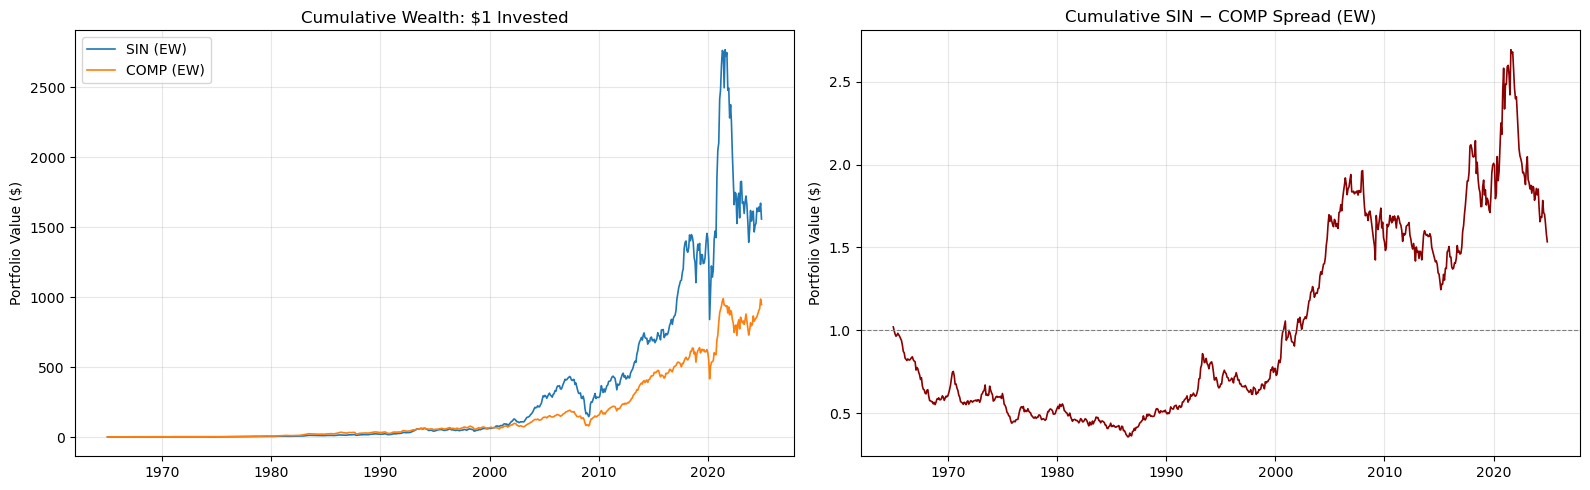

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3b · Cumulative return plot — SIN vs COMP (EW)
# ═══════════════════════════════════════════════════════════════════════════════

cum = portfolios[["ret_sin_ew", "ret_comp_ew", "sin_comp_ew"]].copy()
cum.index = cum.index.to_timestamp()

# Cumulative wealth: $1 invested at t=0
for col in cum.columns:
    cum[col + "_cum"] = (1 + cum[col]).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: Cumulative wealth
ax = axes[0]
ax.plot(cum.index, cum["ret_sin_ew_cum"],  label="SIN (EW)",  linewidth=1.2)
ax.plot(cum.index, cum["ret_comp_ew_cum"], label="COMP (EW)", linewidth=1.2)
ax.set_title("Cumulative Wealth: $1 Invested")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(alpha=0.3)

# Panel B: Cumulative SIN–COMP spread
ax = axes[1]
ax.plot(cum.index, cum["sin_comp_ew_cum"], color="darkred", linewidth=1.2)
ax.axhline(1, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative SIN − COMP Spread (EW)")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4 — Fama–French / Carhart Factor Data

We download monthly factor returns from Ken French's data library (via WRDS):

| Factor | Description |
|--------|-------------|
| **MKT-RF** | Market excess return |
| **SMB** | Small minus Big (size) |
| **HML** | High minus Low (value) |
| **MOM** (UMD) | Up minus Down (momentum) — Carhart (1997) |
| **RF** | Risk-free rate (1-month T-bill) |
| **RMW** | Robust minus Weak (profitability) — FF5 |
| **CMA** | Conservative minus Aggressive (investment) — FF5 |

Sources on WRDS:
- `ff.fivefactors_monthly` → MKT-RF, SMB, HML, RMW, CMA, RF
- `ff.factors_monthly` → MKT-RF, SMB, HML, RF
- `ff.momentum_monthly` → MOM (UMD)

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4 · Download factor data from WRDS (Ken French library)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Fama–French 5 factors ────────────────────────────────────────────────────
ff5 = db.raw_sql("""
    SELECT date, mktrf, smb, hml, rmw, cma, rf
    FROM ff.fivefactors_monthly
""", date_cols=["date"])

ff5["ym"] = ff5["date"].dt.to_period("M")
ff5 = ff5.drop(columns=["date"]).groupby("ym").last()   # one row per month

# ── Momentum (UMD) factor ───────────────────────────────────────────────────
mom = db.raw_sql("""
    SELECT date, umd
    FROM ff.factors_monthly
""", date_cols=["date"])

# In some WRDS versions, momentum is in a separate table
if "umd" not in mom.columns:
    mom = db.raw_sql("""
        SELECT date, umd AS umd
        FROM ff.momentum_monthly
    """, date_cols=["date"])

mom["ym"] = mom["date"].dt.to_period("M")
mom = mom.drop(columns=["date"]).groupby("ym").last()

# ── Merge factors ────────────────────────────────────────────────────────────
factors = ff5.join(mom, how="left")

# WRDS stores factor returns in percent — convert to decimals
for c in ["mktrf", "smb", "hml", "rmw", "cma", "rf", "umd"]:
    if c in factors.columns:
        # Check if already in decimal (values < 1 on average)
        if factors[c].abs().mean() > 0.5:
            factors[c] = factors[c] / 100

print(f"Factor data: {len(factors)} months ({factors.index.min()} → {factors.index.max()})")
print()
print("── Factor means (monthly, decimal) ──")
print(factors.mean().round(5))

Factor data: 750 months (1963-07 → 2025-12)

── Factor means (monthly, decimal) ──
mktrf   0.0059
smb     0.0018
hml     0.0029
rmw     0.0026
cma     0.0024
rf      0.0036
umd     0.0059
dtype: Float64


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4b · Merge portfolio returns with factors
# ═══════════════════════════════════════════════════════════════════════════════

reg_df = portfolios.join(factors, how="inner")

# ── Excess returns ───────────────────────────────────────────────────────────
# The dependent variable for the regressions is the SIN−COMP spread.
# Since it is already a long–short portfolio, the risk-free rate cancels:
#   (R_SIN - R_f) - (R_COMP - R_f) = R_SIN - R_COMP = sin_comp
# But for standalone portfolio alphas, we need excess returns:
reg_df["sin_ew_excess"]  = reg_df["ret_sin_ew"]  - reg_df["rf"]
reg_df["comp_ew_excess"] = reg_df["ret_comp_ew"] - reg_df["rf"]
reg_df["sin_vw_excess"]  = reg_df["ret_sin_vw"]  - reg_df["rf"]
reg_df["comp_vw_excess"] = reg_df["ret_comp_vw"] - reg_df["rf"]

# The spread itself is also run as excess return (= sin_comp since RF cancels)
reg_df["spread_ew"] = reg_df["sin_comp_ew"]
reg_df["spread_vw"] = reg_df["sin_comp_vw"]

print(f"Regression sample: {len(reg_df)} months")
print(f"  {reg_df.index.min()} → {reg_df.index.max()}")
print()
print(reg_df[["spread_ew", "mktrf", "smb", "hml", "umd"]].describe().round(4))

Regression sample: 720 months
  1965-01 → 2024-12

       spread_ew    mktrf      smb      hml      umd
count   720.0000 720.0000 720.0000 720.0000 720.0000
mean      0.0011   0.0058   0.0021   0.0027   0.0060
std       0.0327   0.0452   0.0307   0.0300   0.0424
min      -0.1095  -0.2319  -0.1554  -0.1383  -0.3434
25%      -0.0190  -0.0208  -0.0160  -0.0144  -0.0107
50%       0.0006   0.0094   0.0005   0.0020   0.0070
75%       0.0203   0.0348   0.0202   0.0172   0.0292
max       0.1879   0.1610   0.1846   0.1286   0.1802


## 5 — Asset-Pricing Regressions

We estimate the following models on the SIN − COMP spread:

### A. CAPM
$$R^{SIN-COMP}_t = \alpha + \beta \cdot MKT\text{-}RF_t + \varepsilon_t$$

### B. Carhart 4-Factor Model
$$R^{SIN-COMP}_t = \alpha + \beta_m \cdot MKT\text{-}RF_t + \beta_s \cdot SMB_t + \beta_h \cdot HML_t + \beta_{mom} \cdot MOM_t + \varepsilon_t$$

### C. Fama–French 5-Factor Model (Extension)
$$R^{SIN-COMP}_t = \alpha + \beta_m \cdot MKT\text{-}RF_t + \beta_s \cdot SMB_t + \beta_h \cdot HML_t + \beta_r \cdot RMW_t + \beta_c \cdot CMA_t + \varepsilon_t$$

All regressions use **Newey–West (HAC) standard errors** with automatic bandwidth selection to account for heteroskedasticity and autocorrelation.

The key test: **Is α statistically significantly positive?**  
A positive α means sin stocks earn abnormal excess returns even after controlling for known risk factors — consistent with the social-norm hypothesis.

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5 · Regression helper with Newey–West standard errors
# ═══════════════════════════════════════════════════════════════════════════════

def run_regression(y, X, model_name="Model", nw_lags=None):
    """
    OLS with Newey–West (HAC) standard errors.

    Parameters
    ----------
    y : Series — dependent variable (excess return or spread)
    X : DataFrame — regressors (factors); constant is added automatically
    model_name : str — label for display
    nw_lags : int or None — Newey–West lag truncation; if None, uses int(4*(T/100)^(2/9))

    Returns
    -------
    statsmodels RegressionResults
    """
    data = pd.concat([y.rename("y"), X], axis=1).dropna()
    # Cast to float64 — WRDS nullable dtypes can cause object-array errors
    data = data.astype(float)
    Y = data["y"]
    Xm = sm.add_constant(data.drop(columns=["y"]))

    if nw_lags is None:
        T = len(Y)
        nw_lags = int(np.floor(4 * (T / 100) ** (2 / 9)))

    model = OLS(Y, Xm).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

    print(f"\n{'═'*70}")
    print(f"  {model_name}")
    print(f"  N = {model.nobs:.0f} months | NW lags = {nw_lags}")
    print(f"{'═'*70}")
    print(f"  {'Variable':<12} {'Coef':>10} {'t-stat':>10} {'p-value':>10}")
    print(f"  {'─'*42}")
    for var in model.params.index:
        coef = model.params[var]
        tstat = model.tvalues[var]
        pval = model.pvalues[var]
        sig = ""
        if pval < 0.01:   sig = "***"
        elif pval < 0.05:  sig = "**"
        elif pval < 0.10:  sig = "*"
        label = "alpha" if var == "const" else var
        print(f"  {label:<12} {coef:>10.5f} {tstat:>10.3f} {pval:>10.4f} {sig}")
    print(f"\n  R² = {model.rsquared:.4f}    Adj-R² = {model.rsquared_adj:.4f}")
    print(f"{'═'*70}")

    return model

In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5A · CAPM — SIN−COMP spread
# ═══════════════════════════════════════════════════════════════════════════════

capm = run_regression(
    y=reg_df["spread_ew"],
    X=reg_df[["mktrf"]],
    model_name="CAPM — EW SIN−COMP Spread"
)


══════════════════════════════════════════════════════════════════════
  CAPM — EW SIN−COMP Spread
  N = 720 months | NW lags = 6
══════════════════════════════════════════════════════════════════════
  Variable           Coef     t-stat    p-value
  ──────────────────────────────────────────
  alpha           0.00083      0.617     0.5372 
  mktrf           0.05035      1.421     0.1554 

  R² = 0.0049    Adj-R² = 0.0035
══════════════════════════════════════════════════════════════════════


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5B · Carhart 4-Factor Model — EW SIN−COMP Spread
# ═══════════════════════════════════════════════════════════════════════════════

four_factor = run_regression(
    y=reg_df["spread_ew"],
    X=reg_df[["mktrf", "smb", "hml", "umd"]],
    model_name="Carhart 4-Factor — EW SIN−COMP Spread"
)


══════════════════════════════════════════════════════════════════════
  Carhart 4-Factor — EW SIN−COMP Spread
  N = 720 months | NW lags = 6
══════════════════════════════════════════════════════════════════════
  Variable           Coef     t-stat    p-value
  ──────────────────────────────────────────
  alpha           0.00060      0.441     0.6592 
  mktrf           0.08364      2.821     0.0048 ***
  smb            -0.08963     -1.873     0.0611 *
  hml             0.16583      3.329     0.0009 ***
  umd            -0.03795     -0.696     0.4866 

  R² = 0.0374    Adj-R² = 0.0320
══════════════════════════════════════════════════════════════════════


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5C · Fama–French 5-Factor Model — EW SIN−COMP Spread
# ═══════════════════════════════════════════════════════════════════════════════

ff5_model = run_regression(
    y=reg_df["spread_ew"],
    X=reg_df[["mktrf", "smb", "hml", "rmw", "cma"]],
    model_name="FF 5-Factor — EW SIN−COMP Spread"
)


══════════════════════════════════════════════════════════════════════
  FF 5-Factor — EW SIN−COMP Spread
  N = 720 months | NW lags = 6
══════════════════════════════════════════════════════════════════════
  Variable           Coef     t-stat    p-value
  ──────────────────────────────────────────
  alpha           0.00063      0.479     0.6320 
  mktrf           0.07959      2.531     0.0114 **
  smb            -0.10127     -1.903     0.0570 *
  hml             0.22627      4.070     0.0000 ***
  rmw            -0.04237     -0.670     0.5031 
  cma            -0.10233     -0.984     0.3251 

  R² = 0.0375    Adj-R² = 0.0308
══════════════════════════════════════════════════════════════════════


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5D · Summary table — Alpha comparison across models
# ═══════════════════════════════════════════════════════════════════════════════

def extract_alpha(model, name):
    return {
        "Model": name,
        "Alpha (monthly)":  model.params["const"],
        "Alpha (ann. %)":   model.params["const"] * 12 * 100,
        "t-stat":           model.tvalues["const"],
        "p-value":          model.pvalues["const"],
        "N":                int(model.nobs),
        "R²":               model.rsquared,
    }

alpha_table = pd.DataFrame([
    extract_alpha(capm,       "CAPM"),
    extract_alpha(four_factor,"Carhart 4-Factor"),
    extract_alpha(ff5_model,  "FF 5-Factor"),
])
alpha_table = alpha_table.set_index("Model")

print("\n══════════════════════════════════════════════════════════════")
print("  SIN − COMP Spread: Alpha Estimates (Equal-Weighted)")
print("══════════════════════════════════════════════════════════════")
print(alpha_table.to_string(float_format="{:.4f}".format))
print()
print("A positive, significant alpha indicates that sin stocks earn")
print("abnormal returns above what standard risk factors explain —")
print("consistent with Hong & Kacperczyk's social-norm hypothesis.")


══════════════════════════════════════════════════════════════
  SIN − COMP Spread: Alpha Estimates (Equal-Weighted)
══════════════════════════════════════════════════════════════
                  Alpha (monthly)  Alpha (ann. %)  t-stat  p-value    N     R²
Model                                                                         
CAPM                       0.0008          0.9977  0.6171   0.5372  720 0.0049
Carhart 4-Factor           0.0006          0.7190  0.4411   0.6592  720 0.0374
FF 5-Factor                0.0006          0.7575  0.4789   0.6320  720 0.0375

A positive, significant alpha indicates that sin stocks earn
abnormal returns above what standard risk factors explain —
consistent with Hong & Kacperczyk's social-norm hypothesis.


## 6 — Standalone Portfolio Alphas & Value-Weighted Tests

We also estimate alphas for the **SIN** and **COMP** portfolios individually (not just the spread), and repeat the analysis for **value-weighted** portfolios.

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6 · Full panel: standalone + spread, EW + VW, across models
# ═══════════════════════════════════════════════════════════════════════════════

results_list = []
factor_sets = {
    "CAPM":     ["mktrf"],
    "4-Factor": ["mktrf", "smb", "hml", "umd"],
    "5-Factor": ["mktrf", "smb", "hml", "rmw", "cma"],
}

portfolios_to_test = {
    "SIN (EW)":      "sin_ew_excess",
    "COMP (EW)":     "comp_ew_excess",
    "SIN−COMP (EW)": "spread_ew",
    "SIN (VW)":      "sin_vw_excess",
    "COMP (VW)":     "comp_vw_excess",
    "SIN−COMP (VW)": "spread_vw",
}

for pname, ycol in portfolios_to_test.items():
    for mname, xcols in factor_sets.items():
        data = reg_df[[ycol] + xcols].dropna().astype(float)
        Y = data[ycol]
        X = sm.add_constant(data[xcols])
        T = len(Y)
        nw = int(np.floor(4 * (T / 100) ** (2 / 9)))
        m = OLS(Y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw})

        results_list.append({
            "Portfolio":       pname,
            "Model":           mname,
            "Alpha (mo.)":     m.params["const"],
            "Alpha (ann. %)":  m.params["const"] * 12 * 100,
            "t-stat":          m.tvalues["const"],
            "p-value":         m.pvalues["const"],
            "R²":              m.rsquared,
            "N":               int(m.nobs),
        })

results_table = pd.DataFrame(results_list)

print("══════════════════════════════════════════════════════════════════════════")
print("  Alpha Estimates — All Portfolios & Models  (Newey–West t-stats)")
print("══════════════════════════════════════════════════════════════════════════")
print(
    results_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

══════════════════════════════════════════════════════════════════════════
  Alpha Estimates — All Portfolios & Models  (Newey–West t-stats)
══════════════════════════════════════════════════════════════════════════
    Portfolio    Model  Alpha (mo.)  Alpha (ann. %)  t-stat  p-value     R²   N
     SIN (EW)     CAPM       0.0026          3.1616  1.4068   0.1595 0.5393 720
     SIN (EW) 4-Factor       0.0024          2.8993  1.4984   0.1340 0.6925 720
     SIN (EW) 5-Factor       0.0001          0.0914  0.0515   0.9590 0.6778 720
    COMP (EW)     CAPM       0.0018          2.1639  1.1383   0.2550 0.6317 720
    COMP (EW) 4-Factor       0.0018          2.1803  1.6033   0.1089 0.8262 720
    COMP (EW) 5-Factor      -0.0006         -0.6662 -0.4855   0.6273 0.8169 720
SIN−COMP (EW)     CAPM       0.0008          0.9977  0.6171   0.5372 0.0049 720
SIN−COMP (EW) 4-Factor       0.0006          0.7190  0.4411   0.6592 0.0374 720
SIN−COMP (EW) 5-Factor       0.0006          0.7575  0.4789   0.

## 7 — Extensions

### 7A — Rolling 36-Month Regressions
Estimate the Carhart 4-factor alpha in a 36-month rolling window to see how the sin premium evolves over time.

### 7B — Fama–MacBeth Cross-Sectional Regressions
Run month-by-month cross-sectional regressions of individual stock returns on the SIN dummy and controls, then average the time-series of coefficients (Fama–MacBeth, 1973).

Rolling data: 720 months, cols = ['spread_ew', 'mktrf', 'smb', 'hml', 'umd']
Index range: 1965-01-01 00:00:00 → 2024-12-01 00:00:00
Dtypes:
spread_ew    float64
mktrf        float64
smb          float64
hml          float64
umd          float64
dtype: object

Completed rolling regressions: 684 windows
Completed rolling regressions: 684 windows


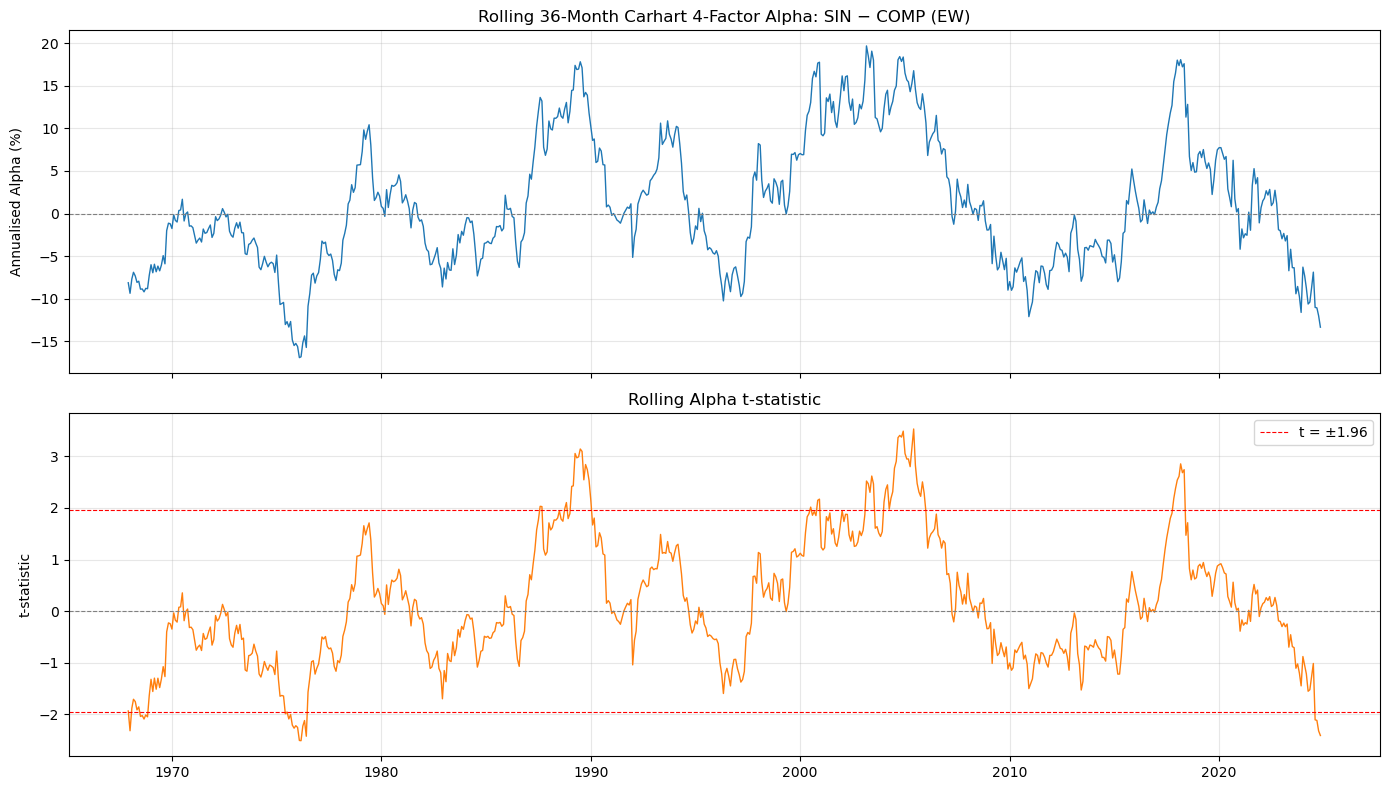

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7A · Rolling 36-month Carhart 4-Factor Alpha
# ═══════════════════════════════════════════════════════════════════════════════

WINDOW = 36  # months

roll_data = reg_df[["spread_ew", "mktrf", "smb", "hml", "umd"]].dropna().copy()
# Cast all columns to float64 (WRDS nullable dtypes break OLS)
for c in roll_data.columns:
    roll_data[c] = roll_data[c].astype(float)
roll_data.index = roll_data.index.to_timestamp()

print(f"Rolling data: {len(roll_data)} months, cols = {list(roll_data.columns)}")
print(f"Index range: {roll_data.index[0]} → {roll_data.index[-1]}")
print(f"Dtypes:\n{roll_data.dtypes}\n")

rolling_alphas = []
rolling_tstats = []
rolling_dates  = []

for end in range(WINDOW, len(roll_data)):
    sub = roll_data.iloc[end - WINDOW : end]
    Y = sub["spread_ew"].values.astype(float)
    X = sm.add_constant(sub[["mktrf", "smb", "hml", "umd"]].values.astype(float))
    try:
        m = OLS(Y, X).fit()
        rolling_alphas.append(m.params[0] * 12)  # annualised (const is index 0)
        rolling_tstats.append(m.tvalues[0])
        rolling_dates.append(sub.index[-1])
    except Exception as e:
        if len(rolling_alphas) == 0:
            print(f"First failure at end={end}: {e}")

print(f"Completed rolling regressions: {len(rolling_alphas)} windows")

roll_alpha_df = pd.DataFrame({
    "date":        rolling_dates,
    "alpha_ann":   rolling_alphas,
    "tstat":       rolling_tstats,
}).set_index("date")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(roll_alpha_df.index, roll_alpha_df["alpha_ann"] * 100, linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_ylabel("Annualised Alpha (%)")
ax.set_title(f"Rolling {WINDOW}-Month Carhart 4-Factor Alpha: SIN − COMP (EW)")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(roll_alpha_df.index, roll_alpha_df["tstat"], linewidth=1, color="tab:orange")
ax.axhline( 1.96, color="red",  linewidth=0.8, linestyle="--", label="t = ±1.96")
ax.axhline(-1.96, color="red",  linewidth=0.8, linestyle="--")
ax.axhline(0,     color="grey", linewidth=0.8, linestyle="--")
ax.set_ylabel("t-statistic")
ax.set_title("Rolling Alpha t-statistic")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7B · Fama–MacBeth Cross-Sectional Regressions
# ═══════════════════════════════════════════════════════════════════════════════
# For each month t, run:
#   R_{i,t} = γ_0,t + γ_1,t * SIN_i + controls + ε_{i,t}
#
# Then report the time-series mean of γ_1 with Newey–West t-stats.
# Controls: log(ME), past-12-month return (momentum proxy)

# ── Prepare firm-level panel ─────────────────────────────────────────────────
fm_df = port_df[["permno", "ym", "ret_adj", "sin", "me"]].dropna(subset=["ret_adj"]).copy()

# Cast numeric cols to float64
for c in ["ret_adj", "sin", "me"]:
    fm_df[c] = fm_df[c].astype(float)

fm_df["log_me"] = np.log(fm_df["me"].clip(lower=0.01))

# Past-12-month return (momentum proxy)
fm_df = fm_df.sort_values(["permno", "ym"])
fm_df["ret12"] = (
    fm_df.groupby("permno")["ret_adj"]
    .transform(lambda x: x.shift(1).rolling(11, min_periods=8).apply(lambda r: (1+r).prod()-1))
)

print(f"FM panel: {len(fm_df):,} firm-months, {fm_df['permno'].nunique():,} unique firms")
fm_clean = fm_df.dropna(subset=["log_me", "ret12"])
print(f"After dropping NaN (log_me, ret12): {len(fm_clean):,} firm-months")
print(f"Unique months: {fm_clean['ym'].nunique()}")

# ── Month-by-month cross-sectional regressions ──────────────────────────────
gamma_list = []
n_fail = 0
first_error = None
for ym, grp in fm_clean.groupby("ym"):
    if len(grp) < 30:
        continue
    Y = grp["ret_adj"].values.astype(float)
    X = sm.add_constant(grp[["sin", "log_me", "ret12"]].values.astype(float))
    try:
        m = OLS(Y, X).fit()
        gamma_list.append({
            "ym": ym,
            "intercept": m.params[0],
            "sin": m.params[1],
            "log_me": m.params[2],
            "ret12": m.params[3],
        })
    except Exception as e:
        n_fail += 1
        if first_error is None:
            first_error = str(e)

print(f"Successful regressions: {len(gamma_list)}, failures: {n_fail}")
if first_error:
    print(f"First error: {first_error}")

gammas = pd.DataFrame(gamma_list).set_index("ym")

# ── Fama–MacBeth estimates: mean of γ with NW t-stats ────────────────────────
T = len(gammas)
nw_lags = int(np.floor(4 * (T / 100) ** (2 / 9)))

print()
print("══════════════════════════════════════════════════════════════")
print("  Fama–MacBeth Cross-Sectional Regression Results")
print(f"  {T} monthly cross-sections, NW lags = {nw_lags}")
print("══════════════════════════════════════════════════════════════")
print(f"  {'Variable':<12} {'Mean γ':>12} {'t-stat':>10} {'p-value':>10}")
print(f"  {'─'*44}")

for col in gammas.columns:
    series = gammas[col].dropna().astype(float)
    mean_g = series.mean()
    # Newey–West t-stat on the mean
    one = np.ones(len(series))
    nw_fit = OLS(series.values, one).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
    t = nw_fit.tvalues[0]
    p = nw_fit.pvalues[0]
    sig = ""
    if p < 0.01:   sig = "***"
    elif p < 0.05: sig = "**"
    elif p < 0.10: sig = "*"
    print(f"  {col:<12} {mean_g:>12.6f} {t:>10.3f} {p:>10.4f} {sig}")

print("══════════════════════════════════════════════════════════════")
print()
print("The coefficient on 'sin' represents the average monthly")
print("return premium for sin stocks after controlling for size")
print("and momentum at the firm level.")

FM panel: 2,638,545 firm-months, 20,057 unique firms
After dropping NaN (log_me, ret12): 2,479,284 firm-months
Unique months: 712
After dropping NaN (log_me, ret12): 2,479,284 firm-months
Unique months: 712
Successful regressions: 712, failures: 0

══════════════════════════════════════════════════════════════
  Fama–MacBeth Cross-Sectional Regression Results
  712 monthly cross-sections, NW lags = 6
══════════════════════════════════════════════════════════════
  Variable           Mean γ     t-stat    p-value
  ────────────────────────────────────────────
  intercept       -0.012314     -2.784     0.0054 ***
  sin             -0.002069     -1.419     0.1559 
  log_me           0.004451     10.014     0.0000 ***
  ret12           -0.004151     -2.259     0.0239 **
══════════════════════════════════════════════════════════════

The coefficient on 'sin' represents the average monthly
return premium for sin stocks after controlling for size
and momentum at the firm level.
Successful regr

## 8 — Methodology Notes & References

### Variable Definitions

| Variable | Definition |
|----------|-----------|
| `ret_adj` | CRSP monthly return compounded with delisting return: $(1+RET)(1+DLRET)-1$ |
| `me` | Market equity = $|PRC| \times SHROUT / 1000$ (in \$M) |
| `sin` | = 1 if firm is Alcohol (SIC 2080–2085), Tobacco (SIC 2100–2199), or Gaming (NAICS 7132xx/72112x) |
| `comp` | = 1 if firm is in FF48 Food (#1), Soda (#3), Fun (#7), or Meals (#43) and NOT sin |
| `spread_ew` | Equal-weighted SIN portfolio return minus equal-weighted COMP portfolio return |
| `spread_vw` | Value-weighted analogue |

### Key Implementation Decisions

1. **Delisting returns:** Following Shumway (1997), we compound DLRET with RET when available. This avoids survivorship bias.
2. **Share codes:** SHRCD ∈ {10, 11} ensures we only include ordinary common shares of US-incorporated firms.
3. **Financial exclusion:** SIC 6000–6999 dropped (standard in cross-sectional asset pricing).
4. **CCM link:** LINKTYPE ∈ {'LU','LC'} and LINKPRIM ∈ {'P','C'} — the standard "best link" filter.
5. **Newey–West:** Bandwidth = $\lfloor 4(T/100)^{2/9} \rfloor$ (Andrews, 1991 rule of thumb).
6. **Gaming segments:** We query `comp.wrds_segmerged` for NAICS codes starting with 7132 or 72112, plus the company-header NAICS.

### References

- Hong, H. & Kacperczyk, M. (2009). *The Price of Sin: The Effects of Social Norms on Markets.* Journal of Financial Economics, 93(1), 15–36.
- Fama, E.F. & French, K.R. (2015). *A Five-Factor Asset Pricing Model.* Journal of Financial Economics, 116(1), 1–22.
- Carhart, M.M. (1997). *On Persistence in Mutual Fund Performance.* Journal of Finance, 52(1), 57–82.
- Fama, E.F. & MacBeth, J.D. (1973). *Risk, Return, and Equilibrium: Empirical Tests.* Journal of Political Economy, 81(3), 607–636.
- Shumway, T. (1997). *The Delisting Bias in CRSP Data.* Journal of Finance, 52(1), 327–340.

In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8 · Export results & disconnect
# ═══════════════════════════════════════════════════════════════════════════════

# ── Save key outputs to CSV ──────────────────────────────────────────────────
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Monthly portfolio returns
portfolios_out = portfolios.copy()
portfolios_out.index = portfolios_out.index.to_timestamp()
portfolios_out.to_csv(f"{output_dir}/sin_comp_portfolio_returns.csv")

# Regression results table
results_table.to_csv(f"{output_dir}/alpha_estimates.csv", index=False)

# Rolling alphas
roll_alpha_df.to_csv(f"{output_dir}/rolling_36m_alphas.csv")

# Fama–MacBeth gammas
gammas_out = gammas.copy()
gammas_out.index = gammas_out.index.to_timestamp()
gammas_out.to_csv(f"{output_dir}/fama_macbeth_gammas.csv")

print("✅ Results saved to ./output/")
print("   • sin_comp_portfolio_returns.csv")
print("   • alpha_estimates.csv")
print("   • rolling_36m_alphas.csv")
print("   • fama_macbeth_gammas.csv")

# ── Close WRDS connection ────────────────────────────────────────────────────
db.close()
print("\n🔒 WRDS connection closed.")

✅ Results saved to ./output/
   • sin_comp_portfolio_returns.csv
   • alpha_estimates.csv
   • rolling_36m_alphas.csv
   • fama_macbeth_gammas.csv

🔒 WRDS connection closed.
